In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score


In [5]:
# Charger le dataset
data = pd.read_excel('Mall_Customers.xlsx')

# Aperçu des données
display(data.head())
display(data.info())


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

In [6]:
# Sélectionner uniquement les colonnes numériques
data_num = data.select_dtypes(include=['int64', 'float64'])
data_num.head()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [7]:
scaler = MinMaxScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data_num), columns=data_num.columns)
data_scaled.head()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,0.000000,0.019231,0.000000,0.387755
1,0.005025,0.057692,0.000000,0.816327
2,0.010050,0.038462,0.008197,0.051020
3,0.015075,0.096154,0.008197,0.775510
4,0.020101,0.250000,0.016393,0.397959


In [8]:
def ACP_personnalisee(data):
    """
    Réalise une ACP manuelle :
    - Calcule la matrice de corrélation
    - Extrait les valeurs propres et vecteurs propres
    - Renvoie la variance expliquée et la projection sur 2 axes
    """
    # Matrice de corrélation
    R = np.corrcoef(data.T)
    
    # Décomposition en valeurs et vecteurs propres
    valeurs_propres, vecteurs_propres = np.linalg.eig(R)
    
    # Tri décroissant
    idx = np.argsort(valeurs_propres)[::-1]
    valeurs_propres = valeurs_propres[idx]
    vecteurs_propres = vecteurs_propres[:, idx]
    
    # Pourcentage d’inertie
    pourcentages = (valeurs_propres / np.sum(valeurs_propres)) * 100
    
    # Nouvelle projection sur 2 axes
    Y = np.dot(data, vecteurs_propres[:, :2])
    
    return valeurs_propres, vecteurs_propres, pourcentages, Y


In [9]:
valeurs_propres, vecteurs_propres, pourcentages, Y = ACP_personnalisee(data_scaled)

print("Valeurs propres :", np.round(valeurs_propres, 3))
print("Pourcentage d’inertie :", np.round(pourcentages, 2))


Valeurs propres : [1.979 1.326 0.673 0.022]
Pourcentage d’inertie : [49.48 33.14 16.82  0.56]


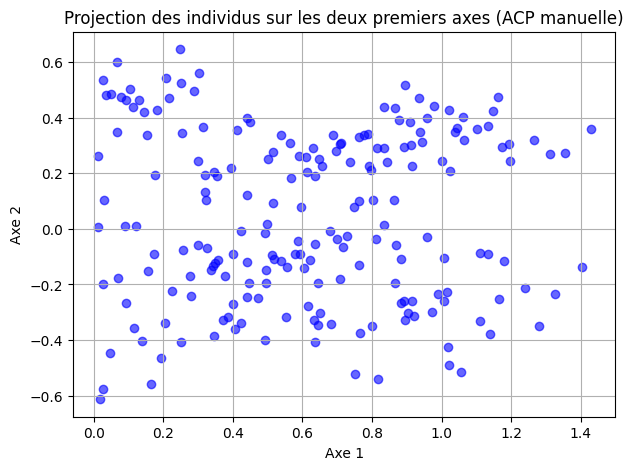

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(Y[:, 0], Y[:, 1], c='blue', alpha=0.6)
plt.title("Projection des individus sur les deux premiers axes (ACP manuelle)")
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.grid(True)
plt.show()


In [11]:
pca = PCA(n_components=2)
Y_sklearn = pca.fit_transform(data_scaled)

print("Variance expliquée par sklearn PCA :", np.round(pca.explained_variance_ratio_ * 100, 2))


Variance expliquée par sklearn PCA : [47.61 34.44]


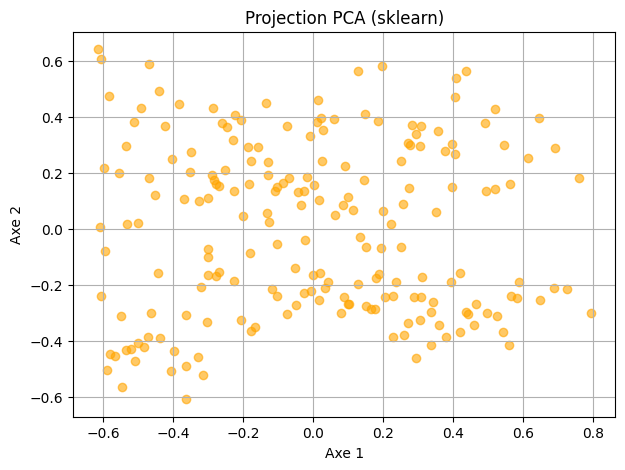

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(Y_sklearn[:, 0], Y_sklearn[:, 1], c='orange', alpha=0.6)
plt.title("Projection PCA (sklearn)")
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.grid(True)
plt.show()


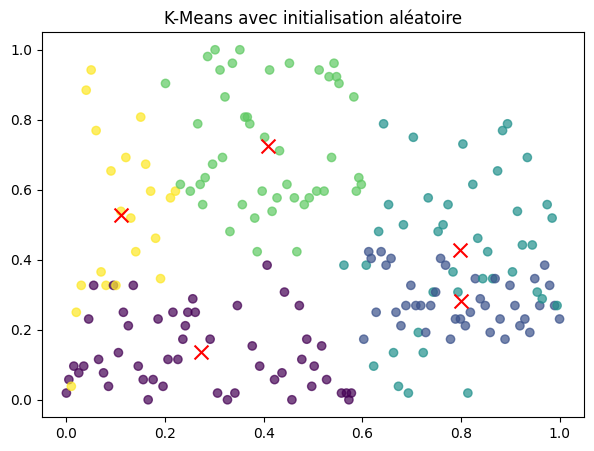

In [14]:
kmeans_random = KMeans(n_clusters=5, init='random', random_state=42)
labels_random = kmeans_random.fit_predict(data_scaled)

plt.figure(figsize=(7,5))
plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels_random, cmap='viridis', alpha=0.7)
plt.scatter(kmeans_random.cluster_centers_[:,0], kmeans_random.cluster_centers_[:,1], c='red', s=100, marker='x')
plt.title("K-Means avec initialisation aléatoire")
plt.show()


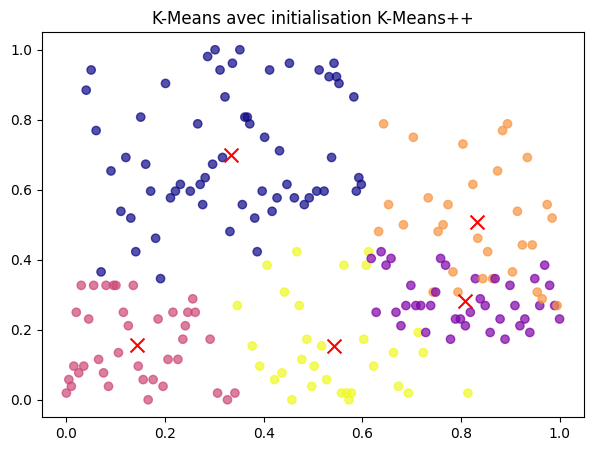

In [15]:
kmeans_plus = KMeans(n_clusters=5, init='k-means++', random_state=42)
labels_plus = kmeans_plus.fit_predict(data_scaled)

plt.figure(figsize=(7,5))
plt.scatter(data_scaled.iloc[:,0], data_scaled.iloc[:,1], c=labels_plus, cmap='plasma', alpha=0.7)
plt.scatter(kmeans_plus.cluster_centers_[:,0], kmeans_plus.cluster_centers_[:,1], c='red', s=100, marker='x')
plt.title("K-Means avec initialisation K-Means++")
plt.show()


In [16]:
score_random = calinski_harabasz_score(data_scaled, labels_random)
score_plus = calinski_harabasz_score(data_scaled, labels_plus)

print(f"Indice Calinski–Harabasz (aléatoire) : {score_random:.2f}")
print(f"Indice Calinski–Harabasz (K-means++) : {score_plus:.2f}")

best_model = "K-Means++" if score_plus > score_random else "Aléatoire"
print("✅ Meilleur modèle :", best_model)


Indice Calinski–Harabasz (aléatoire) : 140.55
Indice Calinski–Harabasz (K-means++) : 136.57
✅ Meilleur modèle : Aléatoire


In [21]:
data_clusters = data.copy()
data_clusters['Cluster'] = labels_plus

# Garder uniquement les colonnes numériques pour le calcul des moyennes
numeric_cols = data_clusters.select_dtypes(include=['int64', 'float64']).columns

clusters_summary = data_clusters.groupby('Cluster')[numeric_cols].mean()
display(clusters_summary)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,67.557377,54.409836,47.098361,41.081967
1,162.000000,32.692308,86.538462,82.128205
2,29.315789,26.210526,29.184211,64.131579
3,166.870968,44.387097,89.774194,18.483871
4,108.838710,25.935484,63.612903,42.612903
